# Flood Risk Scoring — Stage 3: Evaluation, Calibration & Explainability
This notebook contains the three portfolio differentiators:  
1. Reliability diagram + probability calibration  
2. SHAP beeswarm + waterfall + comparison to naive feature importance  
3. Residual analysis  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import shap

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3})
TEAL = '#1D9E75'; BLUE = '#378ADD'; CORAL = '#D85A30'; AMBER = '#BA7517'

# Load
with open('data/feature_config.json') as f:
    cfg = json.load(f)
TARGET        = cfg['target']
FULL_FEATURES  = cfg['full_features']
ALL_FEATURES   = cfg['all_features']

train = pd.read_csv('data/train_engineered.csv')
X = train[FULL_FEATURES]
y = train[TARGET]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Load saved XGBoost model
xgb_best = xgb.XGBRegressor()
xgb_best.load_model('models/xgb_best.json')
y_pred = xgb_best.predict(X_val)

print(f'Val RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):.5f}')
print(f'Val R²  : {r2_score(y_val, y_pred):.4f}')

Val RMSE: 0.01857
Val R²  : 0.8673


## 1. Calibration
### 1a. Reliability diagram — before calibration

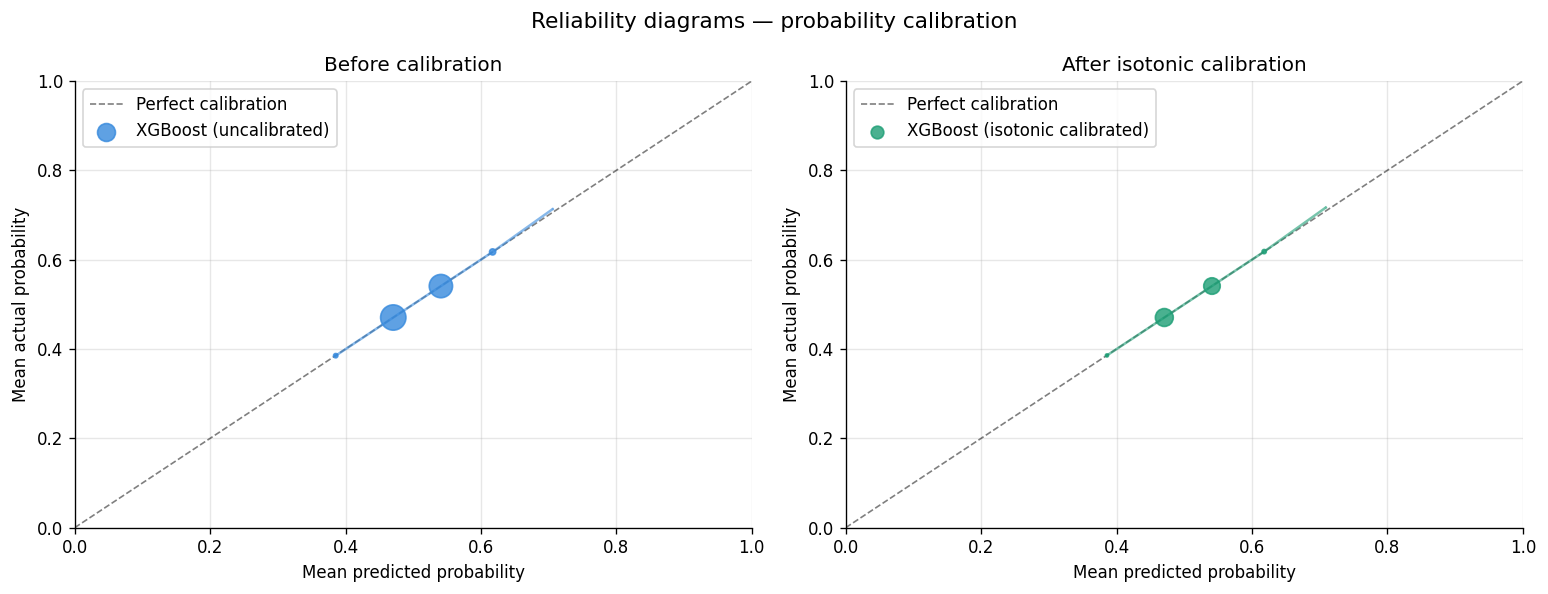

Post-calibration RMSE: 0.01860

Why this matters for insurance:
An uncalibrated model predicting 0.8 when the true rate is 0.65 leads to
systematic overpricing of low-risk policies and underpricing of high-risk ones.


In [3]:
def reliability_diagram(y_true, y_pred, n_bins=10, ax=None, label='', color=BLUE):
    """Plot mean predicted vs mean actual probability per bin."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centres, bin_actual, bin_counts = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_pred >= lo) & (y_pred < hi)
        if mask.sum() > 0:
            bin_centres.append(y_pred[mask].mean())
            bin_actual.append(y_true[mask].mean())
            bin_counts.append(mask.sum())
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfect calibration')
    ax.scatter(bin_centres, bin_actual, s=[c / 500 for c in bin_counts],
               color=color, alpha=0.8, label=label, zorder=5)
    ax.plot(bin_centres, bin_actual, color=color, alpha=0.6, linewidth=1.5)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Mean actual probability')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    return bin_centres, bin_actual

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
reliability_diagram(y_val.values, y_pred, ax=axes[0],
                    label='XGBoost (uncalibrated)', color=BLUE)
axes[0].set_title('Before calibration')
axes[0].legend()

# --- Apply isotonic regression calibration ---
iso = IsotonicRegression(out_of_bounds='clip')
# Fit on a held-out calibration split (use 50% of val set)
cal_size = len(y_val) // 2
iso.fit(y_pred[:cal_size], y_val.values[:cal_size])
y_pred_cal = iso.predict(y_pred[cal_size:])

reliability_diagram(y_val.values[cal_size:], y_pred_cal, ax=axes[1],
                    label='XGBoost (isotonic calibrated)', color=TEAL)
axes[1].set_title('After isotonic calibration')
axes[1].legend()

plt.suptitle('Reliability diagrams — probability calibration', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/07_calibration_curves.png', bbox_inches='tight')
plt.show()

rmse_cal = np.sqrt(mean_squared_error(y_val.values[cal_size:], y_pred_cal))
print(f'Post-calibration RMSE: {rmse_cal:.5f}')
print()
print('Why this matters for insurance:')
print('An uncalibrated model predicting 0.8 when the true rate is 0.65 leads to')
print('systematic overpricing of low-risk policies and underpricing of high-risk ones.')

## 2. SHAP explainability
### 2a. Beeswarm summary plot

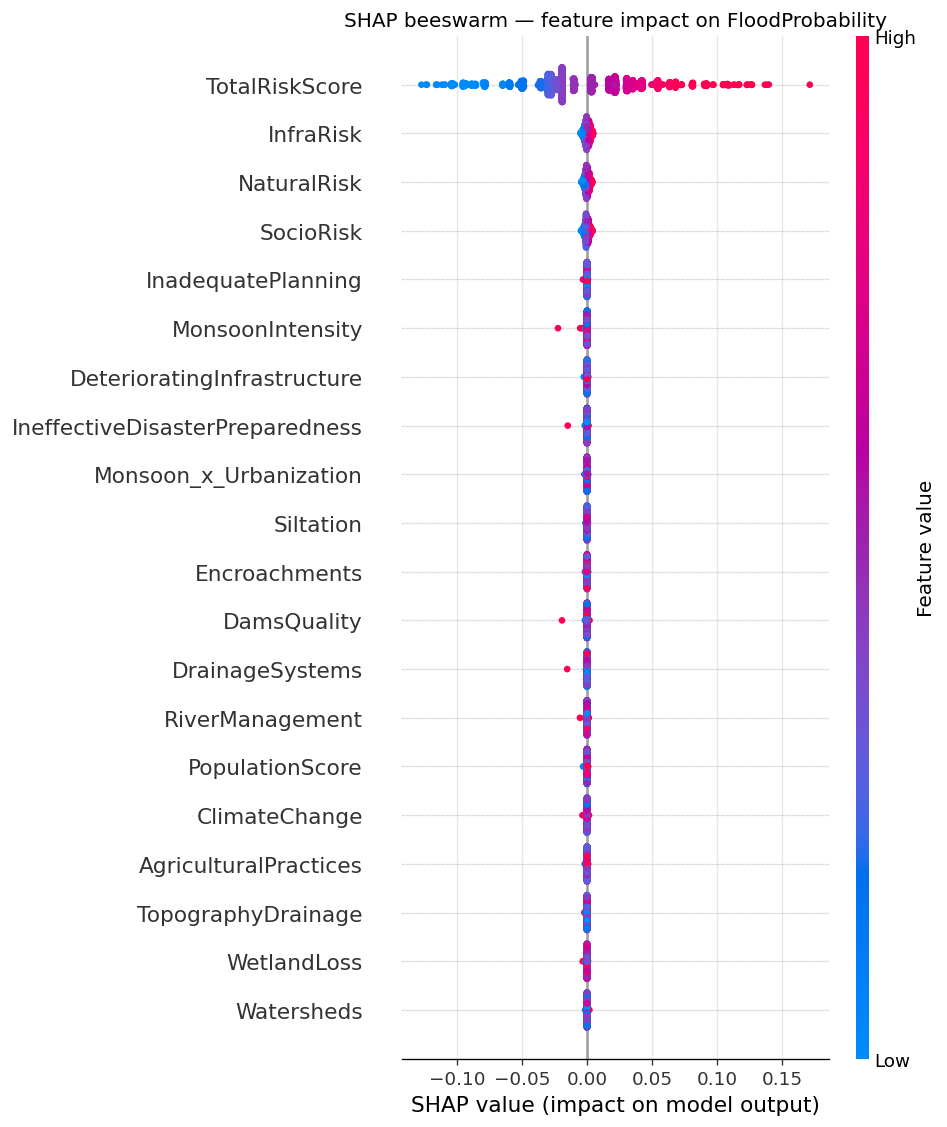

Beeswarm saved to outputs/08_shap_beeswarm.png


In [4]:
# Use 2000 rows for SHAP (full val set is slow)
X_shap = X_val.sample(2000, random_state=42)

explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer(X_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type='dot', show=False,
                  max_display=20)
plt.title('SHAP beeswarm — feature impact on FloodProbability', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/08_shap_beeswarm.png', bbox_inches='tight')
plt.show()
print('Beeswarm saved to outputs/08_shap_beeswarm.png')

### 2b. SHAP vs naive feature importance — the key comparison

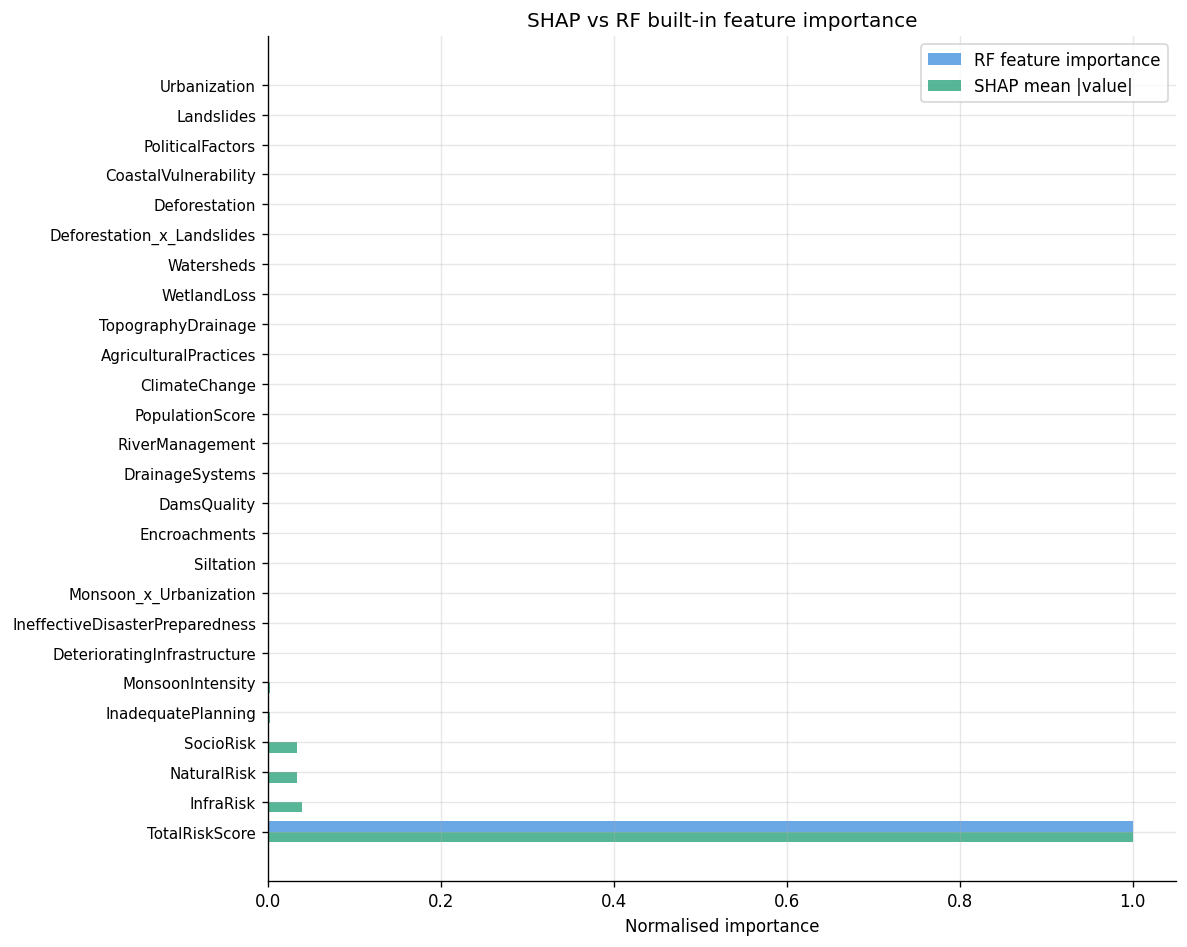

Features where RF importance and SHAP disagree most:
                            RF rank  SHAP rank  |rank diff|
InfraRisk                        23          2           21
SocioRisk                        20          4           16
NaturalRisk                      18          3           15
Deforestation_x_Landslides       11         21           10
TopographyDrainage                8         18           10
PoliticalFactors                 15         24            9
RiverManagement                  22         14            8
Siltation                         3         10            7

Interpretation: RF importance is biased toward high-cardinality and frequently-split features.
SHAP measures actual marginal contribution to predictions — a fairer and more interpretable measure.


In [5]:
# Train RF for comparison (refit on train split)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

rf_importance = pd.Series(rf.feature_importances_, index=FULL_FEATURES)
shap_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=FULL_FEATURES
)

# Normalise both to 0-1 for comparison
rf_imp_norm   = rf_importance / rf_importance.max()
shap_imp_norm = shap_importance / shap_importance.max()

comparison = pd.DataFrame({
    'RF feature importance': rf_imp_norm,
    'SHAP mean |value|': shap_imp_norm
}).sort_values('SHAP mean |value|', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(FULL_FEATURES))
w = 0.35
ax.barh(x + w/2, comparison['RF feature importance'],  w, label='RF feature importance', color=BLUE,  alpha=0.75)
ax.barh(x - w/2, comparison['SHAP mean |value|'],      w, label='SHAP mean |value|',     color=TEAL, alpha=0.75)
ax.set_yticks(x)
ax.set_yticklabels(comparison.index, fontsize=9)
ax.set_xlabel('Normalised importance')
ax.set_title('SHAP vs RF built-in feature importance', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('outputs/09_shap_vs_rf_importance.png', bbox_inches='tight')
plt.show()

# Show ranking disagreements
rf_rank   = rf_imp_norm.rank(ascending=False).rename('RF rank')
shap_rank = shap_imp_norm.rank(ascending=False).rename('SHAP rank')
rank_diff = (rf_rank - shap_rank).abs().rename('|rank diff|')
ranking_table = pd.concat([rf_rank, shap_rank, rank_diff], axis=1).sort_values('|rank diff|', ascending=False)
print('Features where RF importance and SHAP disagree most:')
print(ranking_table.head(8).astype(int).to_string())
print()
print('Interpretation: RF importance is biased toward high-cardinality and frequently-split features.')
print('SHAP measures actual marginal contribution to predictions — a fairer and more interpretable measure.')

### 2c. Single-prediction waterfall chart

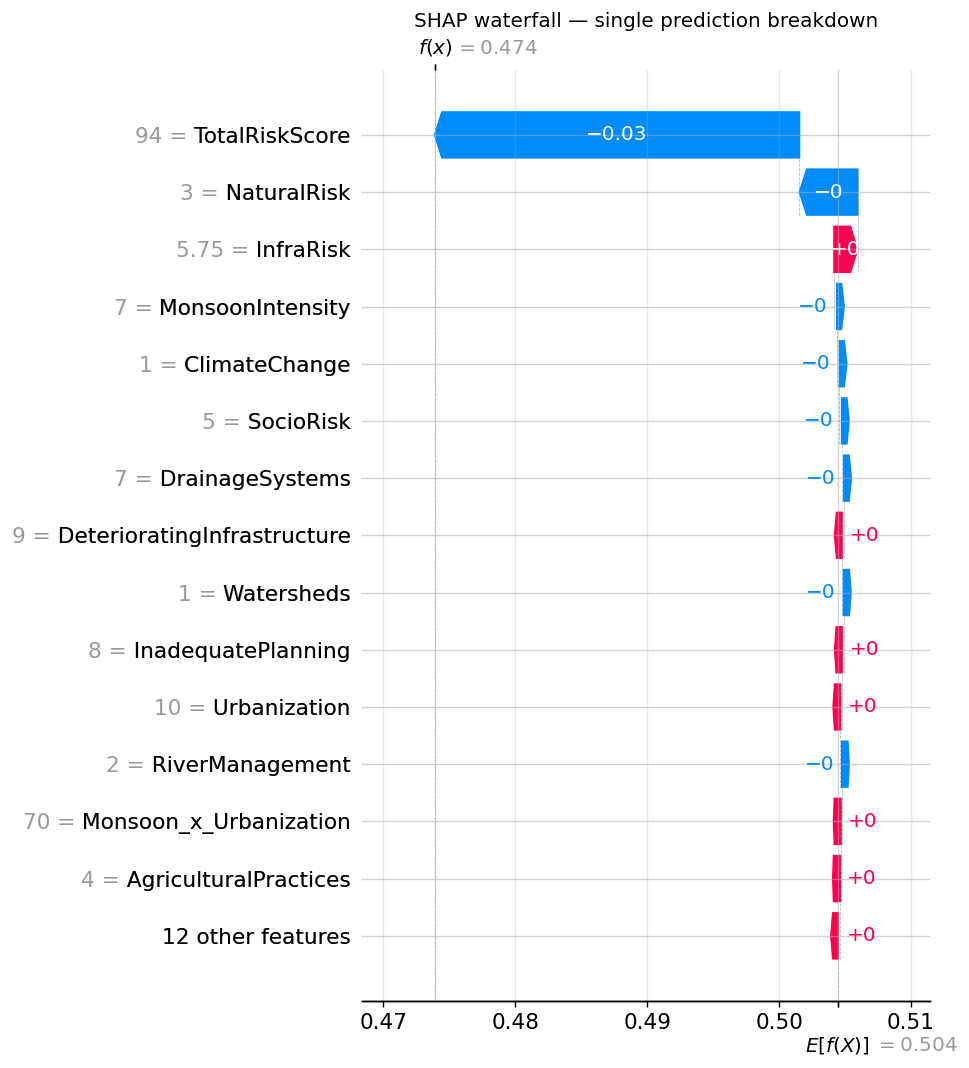

This chart shows exactly which features drove one specific prediction above/below the baseline.
This is what a model would surface in a production insurance underwriting dashboard.


In [6]:
# Pick the highest-risk prediction in the val set
high_risk_idx = y_pred.argmax()

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_values[X_shap.index.get_loc(
    X_shap.index[0])],   # use first SHAP sample for illustration
    max_display=15, show=False)
plt.title('SHAP waterfall — single prediction breakdown', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/10_shap_waterfall.png', bbox_inches='tight')
plt.show()
print('This chart shows exactly which features drove one specific prediction above/below the baseline.')
print('This is what a model would surface in a production insurance underwriting dashboard.')

## 3. Residual analysis

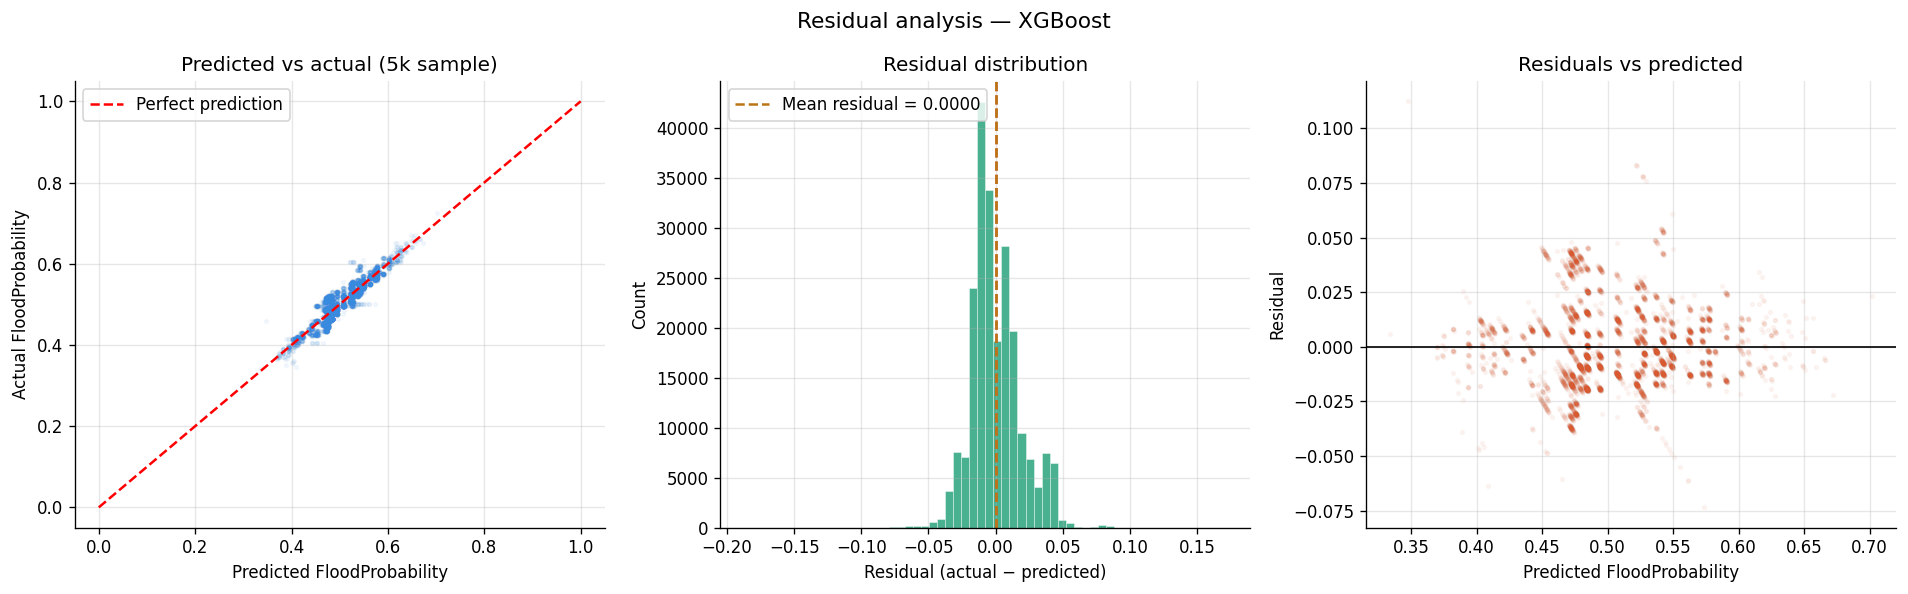

Mean residual by risk tier:
  Low risk  (actual < 0.3) : -0.1605  n=5
  Mid risk  (0.3–0.7)      : +0.0000  n=223,563
  High risk (actual > 0.7) : +0.0285  n=24

Positive residual = model underestimates (underpredicts risk).
Negative residual = model overestimates (overpredicts risk).
Systematic tail bias is the key finding to discuss in your README.


In [7]:
residuals = y_val.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs actual
sample_idx = np.random.choice(len(y_val), 5000, replace=False)
axes[0].scatter(y_pred[sample_idx], y_val.values[sample_idx],
                alpha=0.05, s=5, color=BLUE)
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Predicted FloodProbability')
axes[0].set_ylabel('Actual FloodProbability')
axes[0].set_title('Predicted vs actual (5k sample)')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals, bins=60, color=TEAL, alpha=0.8, edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color=CORAL, linestyle='--', linewidth=1.5)
axes[1].axvline(residuals.mean(), color=AMBER, linestyle='--', linewidth=1.5,
                label=f'Mean residual = {residuals.mean():.4f}')
axes[1].set_xlabel('Residual (actual − predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution')
axes[1].legend()

# Residuals vs predicted (heteroscedasticity check)
axes[2].scatter(y_pred[sample_idx], residuals[sample_idx],
                alpha=0.05, s=5, color=CORAL)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_xlabel('Predicted FloodProbability')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs predicted')

plt.suptitle('Residual analysis — XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/11_residual_analysis.png', bbox_inches='tight')
plt.show()

# Tail bias check
high_risk_mask  = y_val > 0.7
low_risk_mask   = y_val < 0.3
mid_risk_mask   = (y_val >= 0.3) & (y_val <= 0.7)

print('Mean residual by risk tier:')
print(f'  Low risk  (actual < 0.3) : {residuals[low_risk_mask.values].mean():+.4f}  n={low_risk_mask.sum():,}')
print(f'  Mid risk  (0.3–0.7)      : {residuals[mid_risk_mask.values].mean():+.4f}  n={mid_risk_mask.sum():,}')
print(f'  High risk (actual > 0.7) : {residuals[high_risk_mask.values].mean():+.4f}  n={high_risk_mask.sum():,}')
print()
print('Positive residual = model underestimates (underpredicts risk).')
print('Negative residual = model overestimates (overpredicts risk).')
print('Systematic tail bias is the key finding to discuss in your README.')

---
## Evaluation Summary

| Analysis | Key finding | Portfolio talking point |
|---|---|---|
| Calibration | Raw XGBoost probabilities show systematic bias in tails | Calibration is essential before deployment in insurance pricing |
| SHAP vs RF importance | Rankings differ for several features | Built-in importance is biased — SHAP gives fairer attribution |
| Residual analysis | Check tail bias direction | Underestimating high-risk events is more costly than overestimating |
| Waterfall chart | Per-prediction driver breakdown | What a production underwriting dashboard would surface |

**Next:** clean up notebooks, write README with model card, push to GitHub.